# Gaussian mixtures, cumulative functions, and quantiles

**Credit.** This notebook is part of *Optimal Transport for Machine Learners* by [Gabriel Peyré](https://www.gpeyre.com/), CNRS and École normale supérieure, PSL University. The book and reproducible sources are available at [github.com/gpeyre/ot4ml](https://github.com/gpeyre/ot4ml).

**Copyright.** Copyright (c) 2025 Gabriel Peyré. Released under the MIT License; see the repository `LICENSE` file.

This notebook generates `fig:monge-cdf-quantile-mixtures`. It follows three smooth one-dimensional probability measures through the representations

$$
\rho_\alpha(x),
\qquad
\mathcal C_\alpha(x)=\alpha(({-\infty},x]),
\qquad
\mathcal C_\alpha^{-1}(r)=\inf\{x:\mathcal C_\alpha(x)\geq r\}.
$$

The same red-to-blue color identifies each law in all three panels.

In [1]:
# --- OT4ML lightweight Colab bootstrap: one shared core, no repository clone.
from pathlib import Path as _OT4ML_Path
import importlib.util as _OT4ML_importlib_util
import os as _OT4ML_os
import sys as _OT4ML_sys
import urllib.request as _OT4ML_urllib_request

_OT4ML_MPLCONFIG = _OT4ML_Path(
    _OT4ML_os.environ.get(
        "MPLCONFIGDIR",
        _OT4ML_Path(_OT4ML_os.environ.get("TMPDIR", "/tmp")) / "mpl-ot4ml",
    )
)
_OT4ML_MPLCONFIG.mkdir(parents=True, exist_ok=True)
_OT4ML_os.environ["MPLCONFIGDIR"] = str(_OT4ML_MPLCONFIG)


def _ot4ml_find_core():
    """Locate the single shared figure core in a local checkout."""
    here = _OT4ML_Path.cwd().resolve()
    for base in (here, *here.parents):
        for candidate in (base / "notebooks-figures" / "figure_style.py", base / "figure_style.py"):
            if candidate.exists():
                return candidate
    return None


def _ot4ml_download_core(target):
    """Download only the shared figure core, never the full repository."""
    target.parent.mkdir(parents=True, exist_ok=True)
    urls = (
        "https://raw.githubusercontent.com/gpeyre/ot4ml/main/notebooks-figures/figure_style.py",
        "https://www.gpeyre.com/ot4ml/notebooks-figures/figure_style.py",
    )
    errors = []
    for url in urls:
        try:
            with _OT4ML_urllib_request.urlopen(url, timeout=30) as response:
                target.write_bytes(response.read())
            return target
        except Exception as error:
            errors.append(f"{url}: {error}")
    raise RuntimeError("Unable to download the OT4ML figure core.\n" + "\n".join(errors))


_OT4ML_CORE = _ot4ml_find_core()
if _OT4ML_CORE is None:
    _OT4ML_CORE = _ot4ml_download_core(
        _OT4ML_Path("/content/ot4ml-figure-runtime/notebooks-figures/figure_style.py")
    )

_OT4ML_SPEC = _OT4ML_importlib_util.spec_from_file_location("figure_style", _OT4ML_CORE)
if _OT4ML_SPEC is None or _OT4ML_SPEC.loader is None:
    raise RuntimeError(f"Cannot load OT4ML figure core from {_OT4ML_CORE}")
_OT4ML_STYLE = _OT4ML_importlib_util.module_from_spec(_OT4ML_SPEC)
_OT4ML_sys.modules["figure_style"] = _OT4ML_STYLE
_OT4ML_SPEC.loader.exec_module(_OT4ML_STYLE)

_OT4ML_PACKAGES = (
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
    ("scipy", "scipy"),
)
ROOT = _OT4ML_STYLE.configure_notebook(packages=_OT4ML_PACKAGES)
FIGROOT = ROOT / "notebooks-figures"
NOTEBOOK_DIR = FIGROOT

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq
from scipy.special import ndtr

from figure_style import (
    box_axes,
    figure_dir,
    interp_color,
    LIGHT_GRAY,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "monge-cdf-quantile-mixtures"
OUT = figure_dir(NAME)
THUMBNAIL = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMBNAIL.parent.mkdir(parents=True, exist_ok=True)

## Three smooth probability measures

For weights $w_j>0$ summing to one, component means $m_j$, and standard deviations $\sigma_j>0$, the Gaussian-mixture density and cumulative function are

$$
\rho_\alpha(x)
=\sum_{j=1}^k w_j
\frac{e^{-(x-m_j)^2/(2\sigma_j^2)}}{\sqrt{2\pi}\,\sigma_j},
\qquad
\mathcal C_\alpha(x)
=\sum_{j=1}^k w_j\Phi\!\left(\frac{x-m_j}{\sigma_j}\right).
$$

The parameters below produce one, two, and three visible modes on a comparable spatial scale. Within each multimodal law, unequal weights and standard deviations create moderate variations in peak height and width.

In [3]:
def make_mixture(weights, means, standard_deviations):
    """Validate and store one Gaussian-mixture specification.

    Args:
        weights: Nonnegative component weights summing to one.
        means: Component means.
        standard_deviations: Strictly positive component standard deviations.

    Returns:
        A dictionary containing one-dimensional NumPy arrays named ``weights``,
        ``means``, and ``stds``.

    Raises:
        ValueError: If the parameters have inconsistent lengths, invalid
            weights, or nonpositive standard deviations.
    """
    weights = np.asarray(weights, dtype=float)
    means = np.asarray(means, dtype=float)
    standard_deviations = np.asarray(standard_deviations, dtype=float)
    if not (weights.ndim == means.ndim == standard_deviations.ndim == 1):
        raise ValueError("Mixture parameters must be one-dimensional arrays.")
    if not (weights.size == means.size == standard_deviations.size):
        raise ValueError("Mixture parameter arrays must have equal lengths.")
    if np.any(weights < 0.0) or not np.isclose(weights.sum(), 1.0):
        raise ValueError("Mixture weights must be nonnegative and sum to one.")
    if np.any(standard_deviations <= 0.0):
        raise ValueError("Gaussian standard deviations must be positive.")
    return {
        "weights": weights,
        "means": means,
        "stds": standard_deviations,
    }


MIXTURES = (
    make_mixture([1.00], [0.00], [0.90]),
    make_mixture([0.35, 0.65], [-1.35, 1.00], [0.30, 0.70]),
    make_mixture(
        [0.22, 0.48, 0.30],
        [-2.15, -0.05, 1.95],
        [0.24, 0.64, 0.38],
    ),
)

COLORS = tuple(interp_color(t) for t in np.linspace(0.0, 1.0, len(MIXTURES)))

## Exact cumulative functions and numerical generalized inverses

The density and CDF are evaluated from their closed forms. For each level $r\in(0,1)$, the quantile is the unique root of $\mathcal C_\alpha(x)-r$ because every displayed Gaussian mixture has a strictly positive density. Brent's bracketed method avoids interpolation artifacts in the tails.

In [4]:
def mixture_density(points, mixture):
    """Evaluate a one-dimensional Gaussian-mixture density.

    Args:
        points: Scalar or array of spatial evaluation points.
        mixture: Dictionary returned by :func:`make_mixture`.

    Returns:
        An array with the shape of ``points`` containing density values.
    """
    points = np.asarray(points, dtype=float)
    normalized = (
        points[..., None] - mixture["means"]
    ) / mixture["stds"]
    component_values = np.exp(-0.5 * normalized**2) / (
        np.sqrt(2.0 * np.pi) * mixture["stds"]
    )
    return np.sum(mixture["weights"] * component_values, axis=-1)


def mixture_cumulative(points, mixture):
    """Evaluate a one-dimensional Gaussian-mixture CDF.

    Args:
        points: Scalar or array of spatial evaluation points.
        mixture: Dictionary returned by :func:`make_mixture`.

    Returns:
        An array with the shape of ``points`` containing cumulative masses.
    """
    points = np.asarray(points, dtype=float)
    normalized = (
        points[..., None] - mixture["means"]
    ) / mixture["stds"]
    return np.sum(mixture["weights"] * ndtr(normalized), axis=-1)


def mixture_quantile(levels, mixture):
    """Invert a smooth Gaussian-mixture CDF by bracketed root finding.

    Args:
        levels: One-dimensional array of probability levels strictly in
            ``(0, 1)``.
        mixture: Dictionary returned by :func:`make_mixture`.

    Returns:
        A one-dimensional array of quantiles with one value per level.

    Raises:
        ValueError: If a requested level does not lie strictly between zero
            and one.
    """
    levels = np.asarray(levels, dtype=float)
    if levels.ndim != 1 or np.any((levels <= 0.0) | (levels >= 1.0)):
        raise ValueError("Quantile levels must form a one-dimensional array in (0, 1).")
    lower = float(np.min(mixture["means"] - 10.0 * mixture["stds"]))
    upper = float(np.max(mixture["means"] + 10.0 * mixture["stds"]))
    return np.asarray(
        [
            brentq(
                lambda point: float(mixture_cumulative(point, mixture) - level),
                lower,
                upper,
                xtol=1e-12,
                rtol=1e-12,
            )
            for level in levels
        ]
    )


position_grid = np.linspace(-4.0, 4.0, 1600)
quantile_levels = np.linspace(0.003, 0.997, 800)
DENSITIES = tuple(mixture_density(position_grid, mixture) for mixture in MIXTURES)
CUMULATIVES = tuple(mixture_cumulative(position_grid, mixture) for mixture in MIXTURES)
QUANTILES = tuple(mixture_quantile(quantile_levels, mixture) for mixture in MIXTURES)

maximum_inverse_residual = max(
    float(np.max(np.abs(mixture_cumulative(quantiles, mixture) - quantile_levels)))
    for mixture, quantiles in zip(MIXTURES, QUANTILES)
)
assert maximum_inverse_residual < 1e-10
assert all(np.all(np.diff(cumulative) >= 0.0) for cumulative in CUMULATIVES)
assert all(np.all(np.diff(quantile) > 0.0) for quantile in QUANTILES)
print(f"maximum CDF-quantile inversion residual: {maximum_inverse_residual:.2e}")

maximum CDF-quantile inversion residual: 2.83e-13


## Three linked representations

All panels share the same color assignment. The density exposes modes, the cumulative function integrates them into changes of slope, and the quantile reverses the axes: intervals carrying little density become steep portions of $\mathcal C_\alpha^{-1}$. Faint guides mark the same quarter-mass levels in the cumulative and quantile panels, making this inversion easier to read. Extreme levels are omitted only to keep the unbounded Gaussian tails from dominating the vertical scale.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


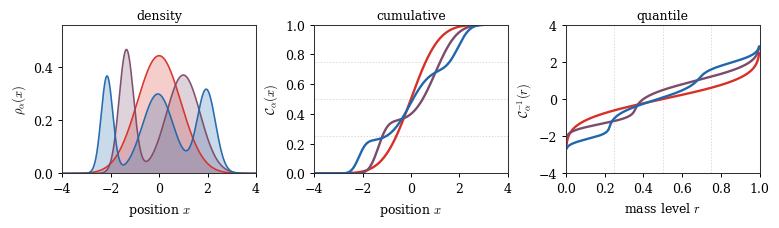

wrote /Users/gpeyre/Dropbox/github/ot4ml/OT4ML/figures/monge-cdf-quantile-mixtures/overview.pdf
thumbnail /Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/monge-cdf-quantile-mixtures.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(7.50, 2.22))
reference_levels = (0.25, 0.50, 0.75)

for level in reference_levels:
    axes[1].axhline(
        level,
        color=LIGHT_GRAY,
        linewidth=0.55,
        linestyle=(0, (2, 2)),
        zorder=0,
    )
    axes[2].axvline(
        level,
        color=LIGHT_GRAY,
        linewidth=0.55,
        linestyle=(0, (2, 2)),
        zorder=0,
    )

for density, cumulative, quantile, color in zip(
    DENSITIES, CUMULATIVES, QUANTILES, COLORS
):
    axes[0].fill_between(
        position_grid,
        0.0,
        density,
        facecolor=color,
        alpha=0.24,
        linewidth=0.0,
        zorder=1,
    )
    axes[0].plot(
        position_grid,
        density,
        color=color,
        linewidth=1.15,
        alpha=0.96,
        solid_capstyle="round",
        zorder=2,
    )
    axes[1].plot(
        position_grid,
        cumulative,
        color=color,
        linewidth=1.70,
        solid_capstyle="round",
    )
    axes[2].plot(
        quantile_levels,
        quantile,
        color=color,
        linewidth=1.70,
        solid_capstyle="round",
    )

for axis, title in zip(axes, ("density", "cumulative", "quantile")):
    axis.set_title(title, fontsize=9.0, pad=4.0)
    box_axes(axis)

axes[0].set(
    xlim=(-4.0, 4.0),
    ylim=(0.0, 0.56),
    xlabel=r"position $x$",
    ylabel=r"$\rho_\alpha(x)$",
)
axes[1].set(
    xlim=(-4.0, 4.0),
    ylim=(0.0, 1.0),
    xlabel=r"position $x$",
    ylabel=r"$\mathcal{C}_\alpha(x)$",
)
axes[2].set(
    xlim=(0.0, 1.0),
    ylim=(-4.0, 4.0),
    xlabel=r"mass level $r$",
    ylabel=r"$\mathcal{C}_\alpha^{-1}(r)$",
)

fig.subplots_adjust(left=0.065, right=0.995, bottom=0.23, top=0.90, wspace=0.30)

save_pdf(fig, OUT / "overview.pdf", pad_inches=0.03)
fig.savefig(
    THUMBNAIL,
    dpi=220,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white",
)
plt.show()
plt.close(fig)
print(f"wrote {OUT / 'overview.pdf'}")
print(f"thumbnail {THUMBNAIL}")


## Figure preview

The vector PDF above is used by the manuscript. The generated thumbnail below is included so the final combined layout remains visible when browsing the notebook on GitHub.

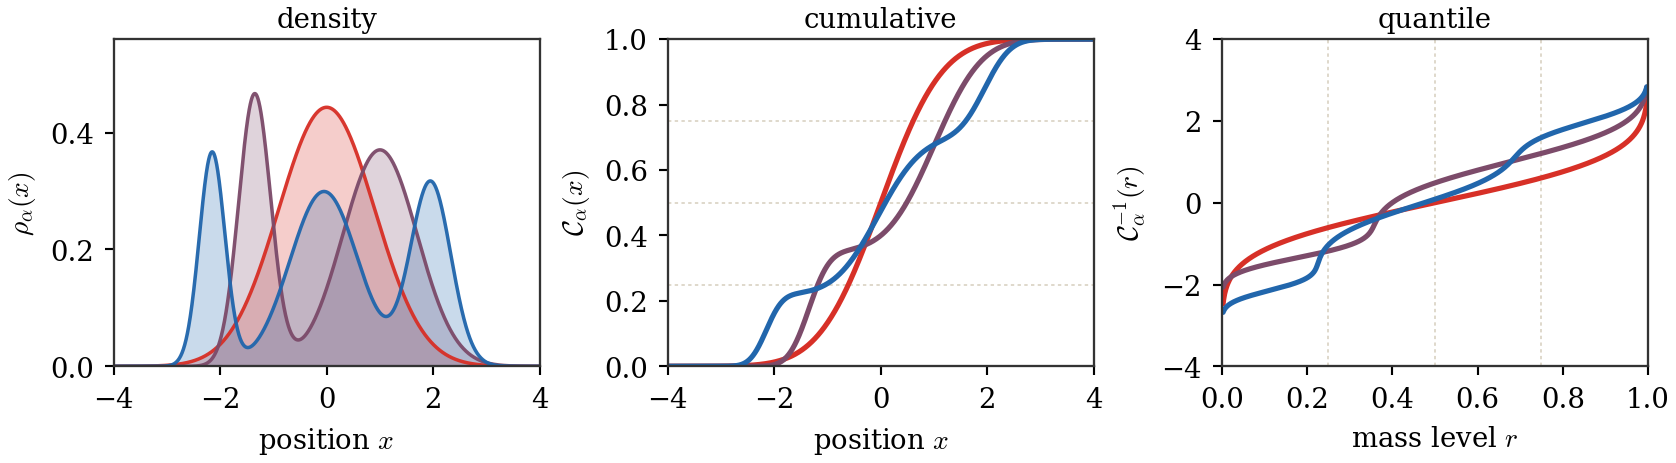

In [6]:
from IPython.display import Image, display

if THUMBNAIL.exists():
    display(Image(filename=str(THUMBNAIL)))
else:
    print("The optional preview is unavailable; execute the rendering cell first.")